# Part A - Environment Setup

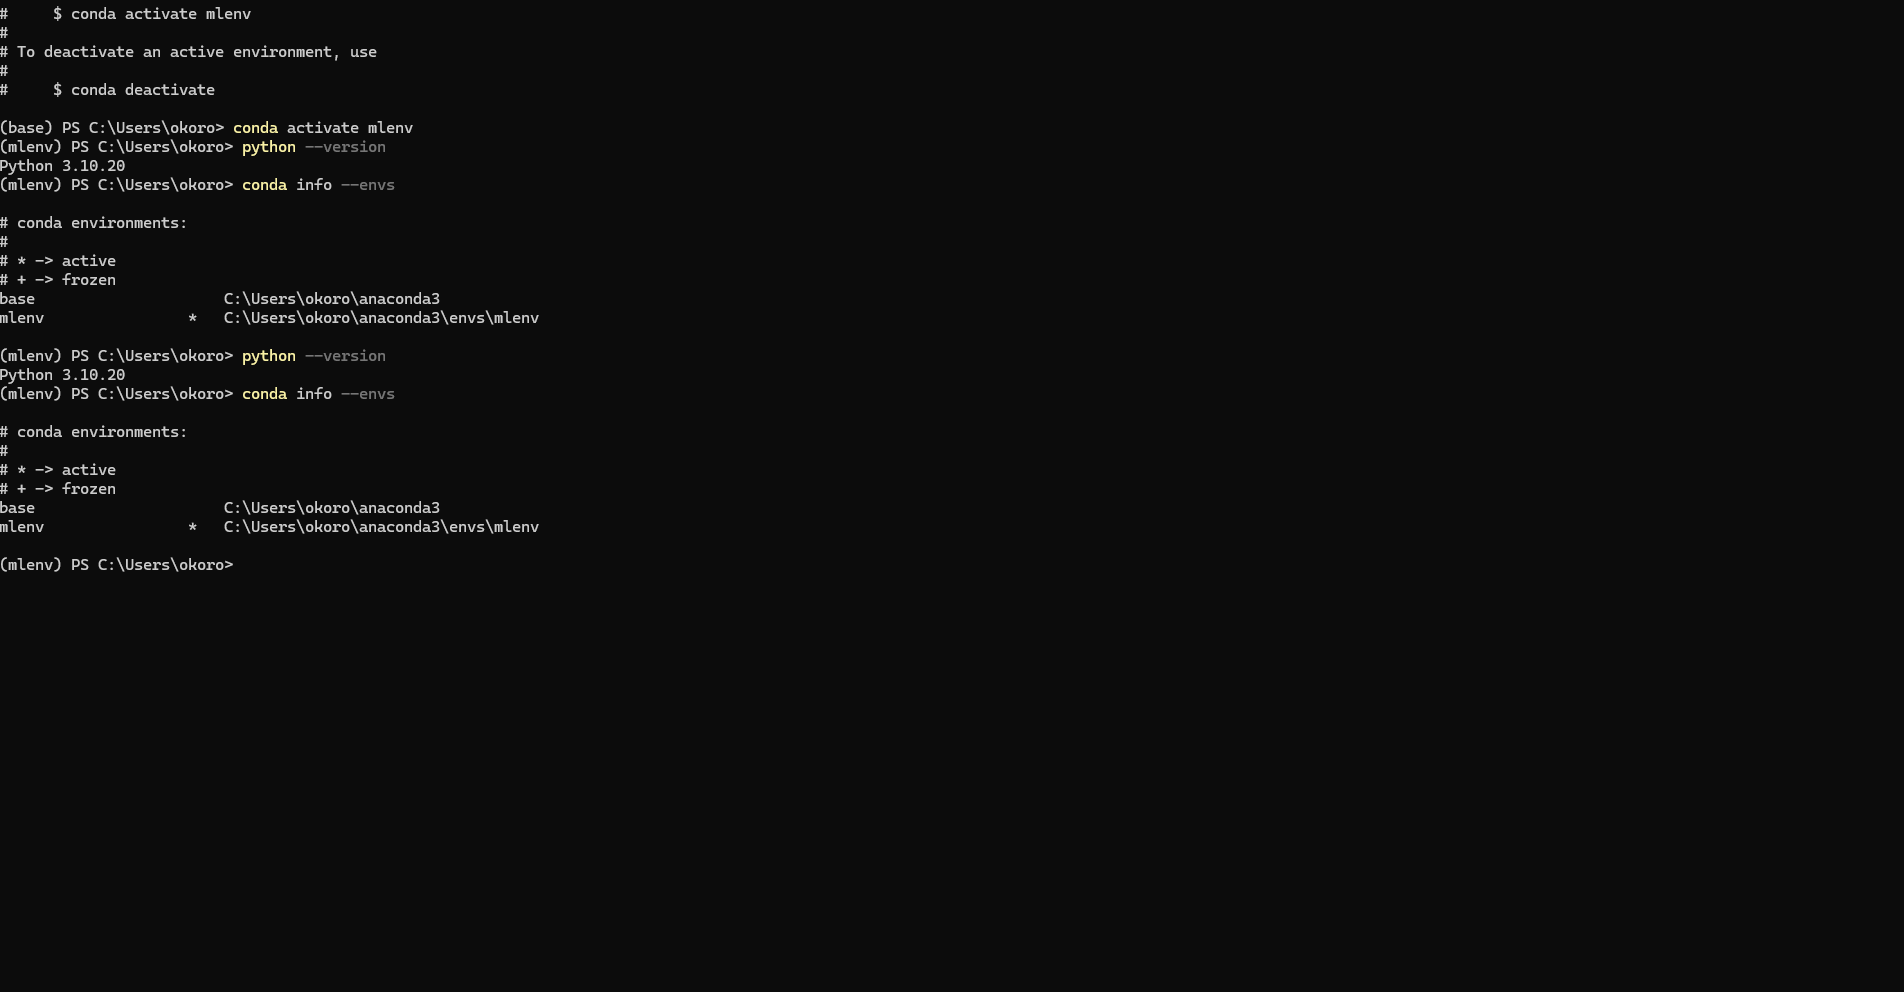

# Part B - Screenshot Evidence

### B1 - Installed Numpy 

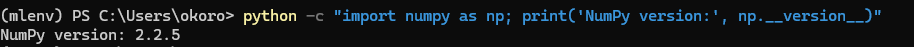

### B2 - Installed Pandas

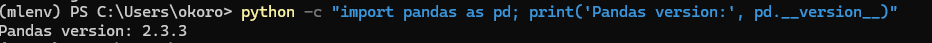

### B3 - Installed matplotlib

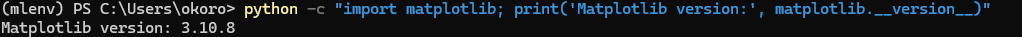

### B4 - Installed Seaborn

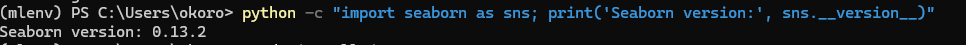

# Part C1 - Coding Tasks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline in the notebook
%matplotlib inline

# Optional: set Seaborn style
sns.set_style('whitegrid')


#### Task 1 - Load the dataset into a DataFrame and print its shape and column names.

In [2]:
df = pd.read_csv(r"C:\Users\okoro\Downloads\911.csv")
print(df.shape)
print(df.columns.tolist())

(663522, 9)
['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']


The shape of the dataset contains 663,522 rows and 9 columns, indicating a large dataset with a substantial amount of information.

The columns include geographic, descriptive, and temporal features. Specifically, 'lat' and 'lng' represent location coordinates, while 'timeStamp' captures when each event occurred. Fields such as 'title' and 'desc' provide categorical and detailed descriptions of the incidents, and 'zip', 'twp', and 'addr' give additional location context. 

#### Task 2 - Display the first 10 rows and the last 5 rows of the dataset.

In [3]:
df.head(10)


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1
5,40.253473,-75.283245,CANNON AVE & W 9TH ST; LANSDALE; Station 345;...,19446.0,EMS: HEAD INJURY,2015-12-10 15:39:04,LANSDALE,CANNON AVE & W 9TH ST,1
6,40.182111,-75.127795,LAUREL AVE & OAKDALE AVE; HORSHAM; Station 35...,19044.0,EMS: NAUSEA/VOMITING,2015-12-10 16:46:48,HORSHAM,LAUREL AVE & OAKDALE AVE,1
7,40.217286,-75.405182,COLLEGEVILLE RD & LYWISKI RD; SKIPPACK; Stati...,19426.0,EMS: RESPIRATORY EMERGENCY,2015-12-10 16:17:05,SKIPPACK,COLLEGEVILLE RD & LYWISKI RD,1
8,40.289027,-75.399590,MAIN ST & OLD SUMNEYTOWN PIKE; LOWER SALFORD;...,19438.0,EMS: SYNCOPAL EPISODE,2015-12-10 16:51:42,LOWER SALFORD,MAIN ST & OLD SUMNEYTOWN PIKE,1
9,40.102398,-75.291458,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD; PLYM...,19462.0,Traffic: VEHICLE ACCIDENT -,2015-12-10 17:35:41,PLYMOUTH,BLUEROUTE & RAMP I476 NB TO CHEMICAL RD,1


#### Task 3    Run df.info() and df.describe(). In your Markdown observation cell, answer: Which columns have missing values? How many?

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB


,lat,lng,zip,e
count,663522.000000,663522.000000,583323.000000,663522.0
mean,40.158162,-75.300105,19236.055791,1.0
std,0.220641,1.672884,298.222637,0.0
min,0.000000,-119.698206,1104.000000,1.0
25%,40.100344,-75.392735,19038.000000,1.0
50%,40.143927,-75.305143,19401.000000,1.0
75%,40.229008,-75.211865,19446.000000,1.0
max,51.335390,87.854975,77316.000000,1.0


The dataset has missing values in the 'zip' and 'twp' columns. 
The 'zip' column contains a large number of missing entries (80,199), while 'twp' has very few (293). 

#### Task 4    The title column contains both the department and the reason in the format DEPARTMENT: REASON. Create two new columns called dept and reason by splitting the title column on the colon character.

In [5]:
df['dept']   = df['title'].apply(lambda x: x.split(':')[0].strip())
df['reason'] = df['title'].apply(lambda x: x.split(':')[1].strip())
print(df[['title', 'dept', 'reason']].head())

                     title  dept              reason
0   EMS: BACK PAINS/INJURY   EMS   BACK PAINS/INJURY
1  EMS: DIABETIC EMERGENCY   EMS  DIABETIC EMERGENCY
2      Fire: GAS-ODOR/LEAK  Fire       GAS-ODOR/LEAK
3   EMS: CARDIAC EMERGENCY   EMS   CARDIAC EMERGENCY
4           EMS: DIZZINESS   EMS           DIZZINESS


### Task 5    Find and print the top 5 townships (twp) by total number of 911 calls.

In [6]:
df['twp'].value_counts().head(5)

twp
LOWER MERION    55490
ABINGTON        39947
NORRISTOWN      37633
UPPER MERION    36010
CHELTENHAM      30574
Name: count, dtype: int64

The top 5 townships with the highest number of 911 calls are LOWER MERION (55,490), ABINGTON (39,947), NORRISTOWN (37,633), UPPER MERION (36,010), and CHELTENHAM (30,574). 
LOWER MERION has the highest number of calls by a significant margin, indicating a higher demand for emergency services compared to the other townships.

### Task 6    Filter the DataFrame to show only EMS calls. How many EMS calls are in the dataset?

In [7]:
# Create a new column for call category
df['reason'] = df['title'].apply(lambda x: x.split(':')[0])

# Filter only EMS calls
ems_calls = df[df['reason'] == 'EMS']
print(ems_calls.head(10))
# Print total number of EMS calls

print("Total EMS calls:", ems_calls.shape[0])

          lat        lng                                               desc  \
0   40.297876 -75.581294  REINDEER CT & DEAD END;  NEW HANOVER; Station ...   
1   40.258061 -75.264680  BRIAR PATH & WHITEMARSH LN;  HATFIELD TOWNSHIP...   
3   40.116153 -75.343513  AIRY ST & SWEDE ST;  NORRISTOWN; Station 308A;...   
4   40.251492 -75.603350  CHERRYWOOD CT & DEAD END;  LOWER POTTSGROVE; S...   
5   40.253473 -75.283245  CANNON AVE & W 9TH ST;  LANSDALE; Station 345;...   
6   40.182111 -75.127795  LAUREL AVE & OAKDALE AVE;  HORSHAM; Station 35...   
7   40.217286 -75.405182  COLLEGEVILLE RD & LYWISKI RD;  SKIPPACK; Stati...   
8   40.289027 -75.399590  MAIN ST & OLD SUMNEYTOWN PIKE;  LOWER SALFORD;...   
16  40.243258 -75.286552  SUSQUEHANNA AVE & W MAIN ST;  LANSDALE; Statio...   
17  40.312181 -75.574260  CHARLOTTE ST & MILES RD;  NEW HANOVER; Station...   

        zip                       title            timeStamp  \
0   19525.0      EMS: BACK PAINS/INJURY  2015-12-10 17:10:52   
1 

The output shows that there are a total of 332,692 EMS calls in the dataset, indicating that EMS incidents make up a significant portion of the recorded 911 calls.

### Task 7 Check how many zip codes are missing. Fill the missing zip code values with 0, then confirm no nulls remain in that column.

In [8]:
# Check number of missing zip codes
missing_zip = df['zip'].isnull().sum()

print("Missing zip codes:", missing_zip)

# Fill missing zip codes with 0
df['zip'] = df['zip'].fillna(0)

# Confirm no null values remain
print("Remaining null values in zip column:", df['zip'].isnull().sum())

Missing zip codes: 80199
Remaining null values in zip column: 0


The dataset contained 80,199 missing values in the 'zip' column. These missing values were replaced with 0 using the `fillna()` method. After the replacement, the column was checked again and confirmed to have no remaining null values.

### Summary
1. The dataset contains 663,522 records and 9 main columns.
2. EMS (Emergency Medical Services) was the department with the highest number of calls, with a total of 332,692 incidents recorded.
3. LOWER MERION was the most active township, recording the highest number of 911 calls among all townships in the dataset.
4. The dataset contained missing values mainly in the 'zip' and 'twp' columns, with the 'zip' column having over 80,000 missing entries before cleaning.

# PART C2 - NumPy: Numerical Analysis on 911 Data

### Task 1 - Extract the lat and lng columns as NumPy arrays. Print the data type and shape of each.

In [9]:
# Extract lat and lng columns as NumPy arrays
lat_array = df['lat'].to_numpy()
lng_array = df['lng'].to_numpy()

# Print data type and shape
print("Latitude Array Type:", type(lat_array))
print("Latitude Array Shape:", lat_array.shape)

print("Longitude Array Type:", type(lng_array))
print("Longitude Array Shape:", lng_array.shape)

Latitude Array Type: <class 'numpy.ndarray'>
Latitude Array Shape: (663522,)
Longitude Array Type: <class 'numpy.ndarray'>
Longitude Array Shape: (663522,)


Both lat and lng are of the ndarray type and they contain 663,522 elements, which corresponds with the total number of records.

### Task 2    Calculate and print the following statistics for the lat column: mean, standard deviation, minimum, maximum, and the range (max - min).

In [10]:
# Calculate statistics for the lat column
lat_mean = df['lat'].mean()
lat_std = df['lat'].std()
lat_min = df['lat'].min()
lat_max = df['lat'].max()
lat_range = lat_max - lat_min

# Print results
print("Mean Latitude:", lat_mean)
print("Standard Deviation:", lat_std)
print("Minimum Latitude:", lat_min)
print("Maximum Latitude:", lat_max)
print("Latitude Range:", lat_range)

Mean Latitude: 40.15816213997109
Standard Deviation: 0.2206414382812337
Minimum Latitude: 0.0
Maximum Latitude: 51.3353899
Latitude Range: 51.3353899


The latitude data shows that most incidents occurred within a concentrated geographic region centered around latitude 40.16. The low standard deviation indicates that the locations are closely clustered, while the minimum value of 0.0 suggests the presence of invalid or missing data. Additionally, the maximum latitude value appears to be an outlier outside the main coverage area.


### Task 3    Count the number of calls from each department using value_counts(), then convert the result to a NumPy array of counts. Calculate the total calls, and the percentage share of each department.

In [11]:
# Count calls from each department
dept_counts = df['dept'].value_counts()

print("Department Call Counts:")
print(dept_counts)

# Convert counts to NumPy array
dept_counts_array = dept_counts.to_numpy()

print("\nNumPy Array of Counts:")
print(dept_counts_array)

# Calculate total calls
total_calls = dept_counts.sum()

print("\nTotal Calls:", total_calls)

# Calculate percentage share of each department
dept_percentage = (dept_counts / total_calls) * 100

print("\nPercentage Share:")
for dept, pct in zip(dept_counts.index, dept_percentage):
    print(f"{dept}: {pct:.2f}%")

Department Call Counts:
dept
EMS        332692
Traffic    230208
Fire       100622
Name: count, dtype: int64

NumPy Array of Counts:
[332692 230208 100622]

Total Calls: 663522

Percentage Share:
EMS: 50.14%
Traffic: 34.69%
Fire: 15.16%


The analysis shows that the EMS department handled the highest number of emergency calls, accounting for 50.14% of all incidents in the dataset. Traffic-related calls made up 34.69% of the total calls, while the Fire department handled the smallest share at 15.16%. This indicates that medical emergencies were the most common type of incident recorded in the dataset.

### Task 4: The timeStamp column is currently a string. Convert it to datetime, then extract the hour of each call as a NumPy array. Use np.bincount() to count how many calls occurred in each hour (0 to 23).

In [12]:
# Convert timeStamp column to datetime
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

# Extract hour from each call
hours = df['timeStamp'].dt.hour.to_numpy()

# Count calls for each hour (0–23)
hour_counts = np.bincount(hours, minlength=24)

# Print results
print("Hour Array:")
print(hours)

print("\nCalls Per Hour:")
for hour, count in enumerate(hour_counts):
    print(f"Hour {hour}: {count} calls")

Hour Array:
[17 17 14 ... 15 15 15]

Calls Per Hour:
Hour 0: 13863 calls
Hour 1: 11751 calls
Hour 2: 10653 calls
Hour 3: 9488 calls
Hour 4: 9265 calls
Hour 5: 11676 calls
Hour 6: 17219 calls
Hour 7: 26971 calls
Hour 8: 33380 calls
Hour 9: 35477 calls
Hour 10: 36577 calls
Hour 11: 38076 calls
Hour 12: 40097 calls
Hour 13: 39797 calls
Hour 14: 40346 calls
Hour 15: 42263 calls
Hour 16: 42797 calls
Hour 17: 44119 calls
Hour 18: 37322 calls
Hour 19: 32442 calls
Hour 20: 28079 calls
Hour 21: 24659 calls
Hour 22: 20313 calls
Hour 23: 16892 calls


The analysis shows that emergency call activity varies significantly throughout the day. Call volumes are lowest during the early morning hours, particularly between 2 AM and 5 AM, when most people are likely asleep and overall activity is reduced. Emergency calls begin increasing rapidly from 6 AM onward and peak during the late afternoon and early evening hours.

The highest number of calls occurred at 5 PM (Hour 17) with 44,119 calls, indicating that emergency activity is greatest during busy daytime and commuting periods. After 6 PM, the number of calls gradually declines into the night. Overall, the data suggests that emergency incidents are most common during active daytime hours and least common during overnight hours.

### Task 5    Use boolean masking on your hour_arr to find: how many calls occurred between 08:00 and 18:00 (daytime), and how many outside that range (nighttime).

In [13]:
# Boolean masking for daytime calls (08:00 to 18:00)
daytime_calls = hours[(hours >= 8) & (hours <= 18)]

# Boolean masking for nighttime calls
nighttime_calls = hours[(hours < 8) | (hours > 18)]

# Count calls
print("Daytime Calls:", len(daytime_calls))
print("Nighttime Calls:", len(nighttime_calls))

Daytime Calls: 430251
Nighttime Calls: 233271


The analysis shows that most emergency calls occurred during daytime hours between 8 AM and 6 PM. A total of 430,251 calls were recorded during the daytime, compared to 233,271 calls during nighttime hours. This indicates that emergency activity is significantly higher during active daytime periods, likely due to increased movement, commuting, work activities, and public interaction.

### Summary
Working with NumPy arrays makes numerical computations faster and more efficient, especially when handling large datasets like this emergency call dataset. By converting Pandas columns into NumPy arrays, it becomes easier to perform mathematical operations, statistical analysis, and array-based processing using NumPy functions. I would prefer using np.mean() when working directly with extracted NumPy arrays or when combining multiple numerical operations in a computation workflow. However, df['col'].mean() is more convenient during DataFrame analysis because it is simpler to read and automatically handles missing values within the dataset.

# PART C3 — Matplotlib: Visualising the 911 Data

### Task 1    Create a bar chart showing the total number of calls for each department (EMS, Fire, Traffic). Use a different colour for each bar.

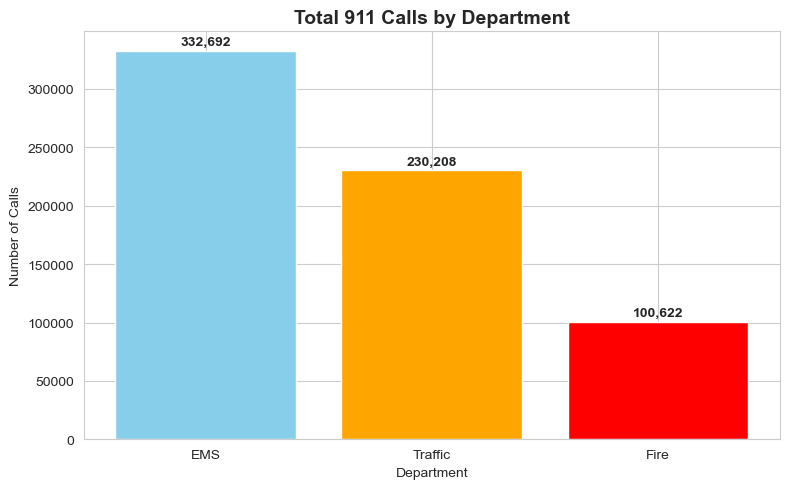

In [14]:
# Count calls by department
dept_counts = df['dept'].value_counts()

# Create figure
plt.figure(figsize=(8,5))

# Create bar chart
bars = plt.bar(
    dept_counts.index,
    dept_counts.values,
    color=['skyblue', 'orange', 'red']
)

# Add title and labels
plt.title('Total 911 Calls by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Calls')

# Add actual values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5000,
        f'{height:,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The bar chart shows that the EMS department handled the highest number of emergency calls, followed by Traffic and Fire departments. EMS calls were significantly more frequent than the other categories, indicating that medical emergencies make up the largest portion of incidents in the dataset.

### Task 2    Create a histogram showing the distribution of calls by hour of day (0 to 23). Set bins=24. Identify visually the peak hour for emergency calls.

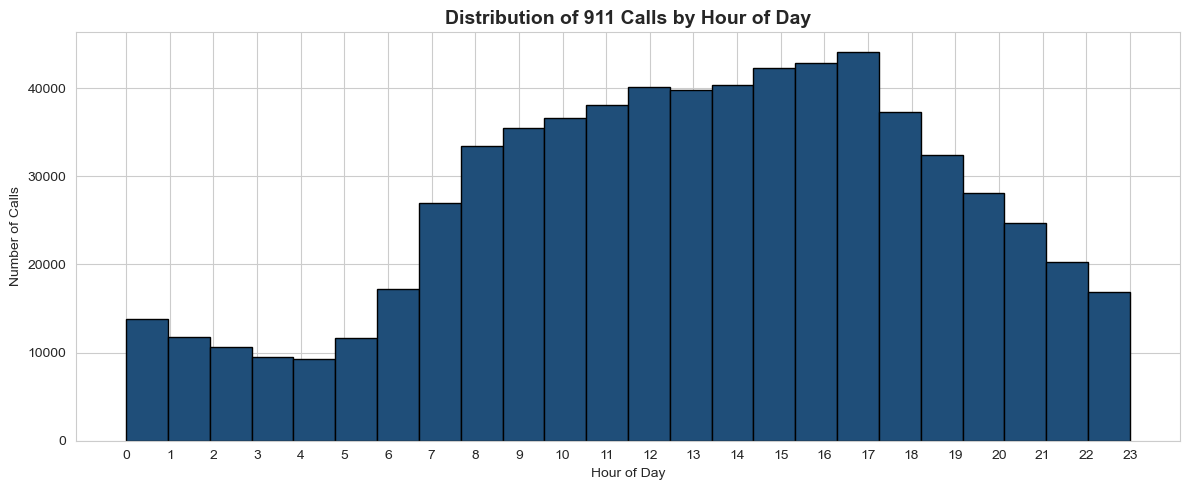

In [15]:
# Create figure
plt.figure(figsize=(12,5))

# Histogram of calls by hour
plt.hist(hours, bins=24, color='#1f4e79', edgecolor='black')

# Add title and labels
plt.title('Distribution of 911 Calls by Hour of Day',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Calls')

# Set x-axis ticks
plt.xticks(range(24))

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The histogram shows that emergency call activity increases steadily during the morning hours and reaches its peak in the late afternoon. Visually, the highest concentration of calls occurs around 5 PM (Hour 17), indicating that emergency incidents are most common during busy daytime and commuting periods. Call activity is lowest during the early morning hours between 2 AM and 5 AM.

### Task 3    Create a horizontal bar chart of the top 10 townships by call volume. Sort the bars so the highest is at the top.

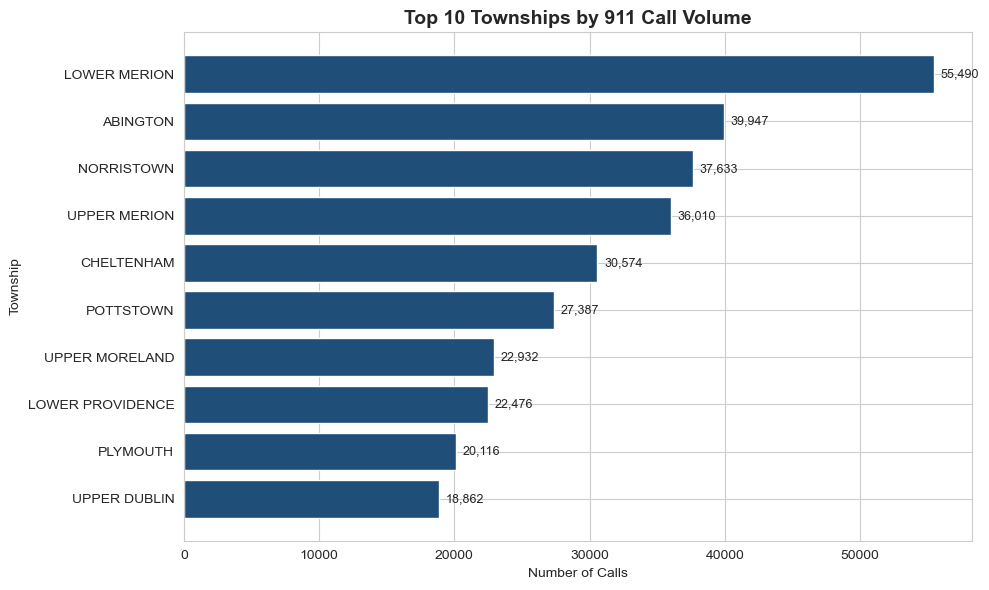

In [16]:
# Get top 10 townships by call volume
top_twp = df['twp'].value_counts().head(10)

# Create figure
plt.figure(figsize=(10,6))

# Create horizontal bar chart
bars = plt.barh(
    top_twp.index,
    top_twp.values,
    color='#1f4e79'
)

# Invert y-axis so highest appears at the top
plt.gca().invert_yaxis()

# Add title and labels
plt.title('Top 10 Townships by 911 Call Volume',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Number of Calls')
plt.ylabel('Township')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f'{width:,}',
        va='center',
        fontsize=9
    )

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The horizontal bar chart highlights the top 10 townships with the highest emergency call volumes. LOWER MERION recorded the highest number of calls, followed by ABINGTON and NORRISTOWN. Sorting the bars in descending order makes it easier to compare township activity levels and quickly identify the areas with the greatest demand for emergency services.

### Task 4    Create a line chart showing the total number of 911 calls per month. First extract the month from the timeStamp column, group by month, and count calls.

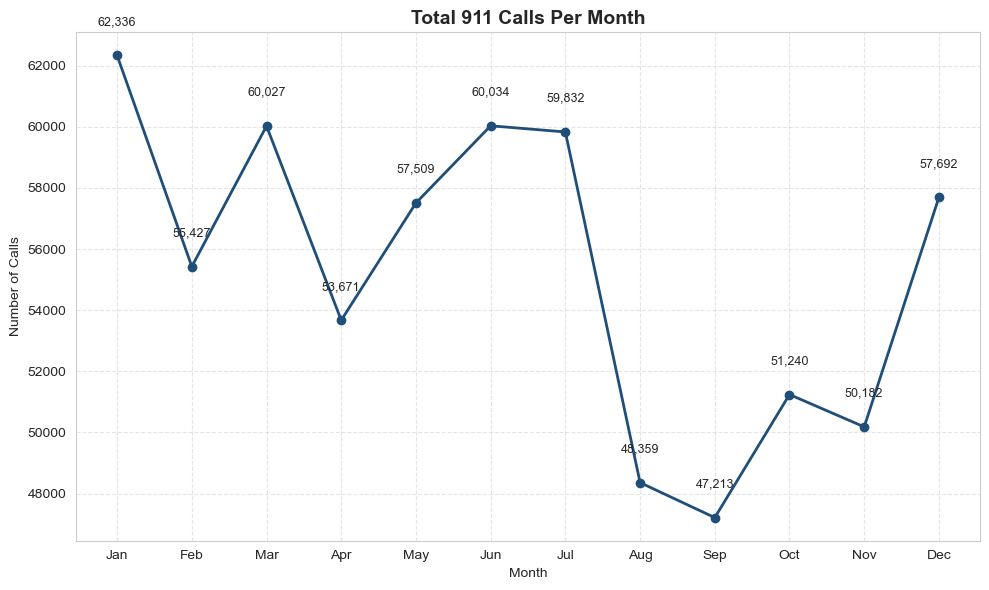

In [17]:
# Extract month from timeStamp
df['Month'] = df['timeStamp'].dt.month

# Group by month and count calls
monthly_calls = df.groupby('Month').size()

# Month abbreviations
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create line chart
plt.figure(figsize=(10,6))

plt.plot(
    monthly_calls.index,
    monthly_calls.values,
    marker='o',
    linewidth=2,
    color='#1f4e79'
)

# Add title and labels
plt.title('Total 911 Calls Per Month',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Month')
plt.ylabel('Number of Calls')

# Replace month numbers with abbreviations
plt.xticks(range(1,13), month_labels)

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add value labels
for x, y in zip(monthly_calls.index, monthly_calls.values):
    plt.text(x, y + 1000, f'{y:,}',
             ha='center',
             fontsize=9)

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The visualization shows clear monthly fluctuations in emergency call activity throughout the year. January recorded the highest number of calls with 62,336 incidents, indicating a particularly active start to the year. Call volumes remained relatively high between March and July, with June and July also showing strong emergency activity above 59,000 calls.

A significant decline occurred between August and September, where September recorded the lowest number of calls at 47,213. After September, emergency call volumes gradually increased again toward the end of the year, with December rising to 57,692 calls.

### 

### Write observations for each chart. For the hourly histogram: what time of day sees the most emergency calls and why might this be? For the monthly line chart: do you notice any seasonal trends?
* The bar chart shows that the EMS department handled the highest number of emergency calls, followed by Traffic and Fire departments. EMS calls were significantly more frequent than the other categories, indicating that medical emergencies make up the largest portion of incidents in the dataset.

* The histogram shows that emergency call activity increases steadily during the morning hours and reaches its peak in the late afternoon. Visually, the highest concentration of calls occurs around 5 PM (Hour 17), indicating that emergency incidents are most common during busy daytime and commuting periods. Call activity is lowest during the early morning hours between 2 AM and 5 AM.

* The horizontal bar chart highlights the top 10 townships with the highest emergency call volumes. LOWER MERION recorded the highest number of calls, followed by ABINGTON and NORRISTOWN. Sorting the bars in descending order makes it easier to compare township activity levels and quickly identify the areas with the greatest demand for emergency services.

* The visualization shows clear monthly fluctuations in emergency call activity throughout the year. January recorded the highest number of calls with 62,336 incidents, indicating a particularly active start to the year. Call volumes remained relatively high between March and July, with June and July also showing strong emergency activity above 59,000 calls.

* A significant decline occurred between August and September, where September recorded the lowest number of calls at 47,213. After September, emergency call volumes gradually increased again toward the end of the year, with December rising to 57,692 calls.


# Part C4 — Seaborn: Statistical Visualisation

### Task 1    Create a countplot showing the number of calls per department. Use the palette parameter to apply a colour palette of your choice.

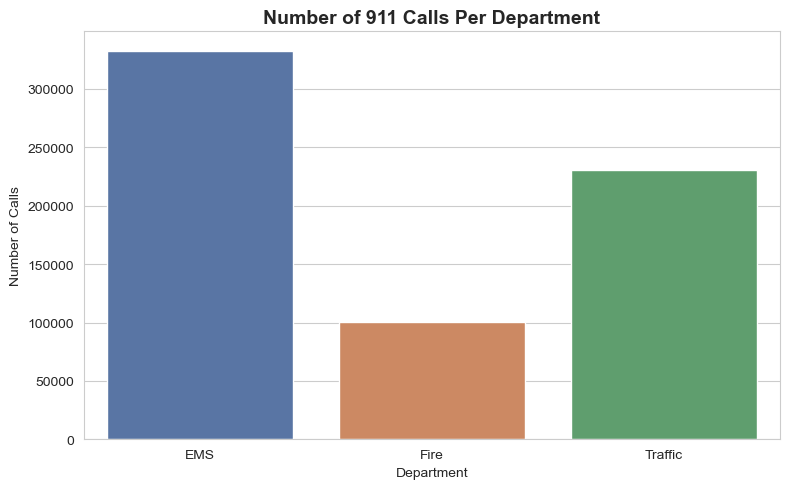

In [18]:
# Create figure
plt.figure(figsize=(8,5))

# Create countplot
sns.countplot(
    data=df,
    x='dept',
    hue='dept',
    palette='deep',
    legend=False
)

# Add title and labels
plt.title('Number of 911 Calls Per Department',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Department')
plt.ylabel('Number of Calls')

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The countplot clearly shows that the EMS department handled the highest number of 911 calls, with call volumes significantly exceeding those of the other departments. Traffic-related incidents recorded the second-highest number of calls, while the Fire department handled the fewest incidents. The large gap between EMS and Fire calls suggests that medical emergencies occur far more frequently than fire-related incidents within the dataset. Overall, the chart highlights the unequal distribution of emergency service demand across departments.

### Task 2    Create a heatmap showing the number of calls by day of week (0=Monday, 6=Sunday) and hour of day. First create a pivot table using the day and hour columns

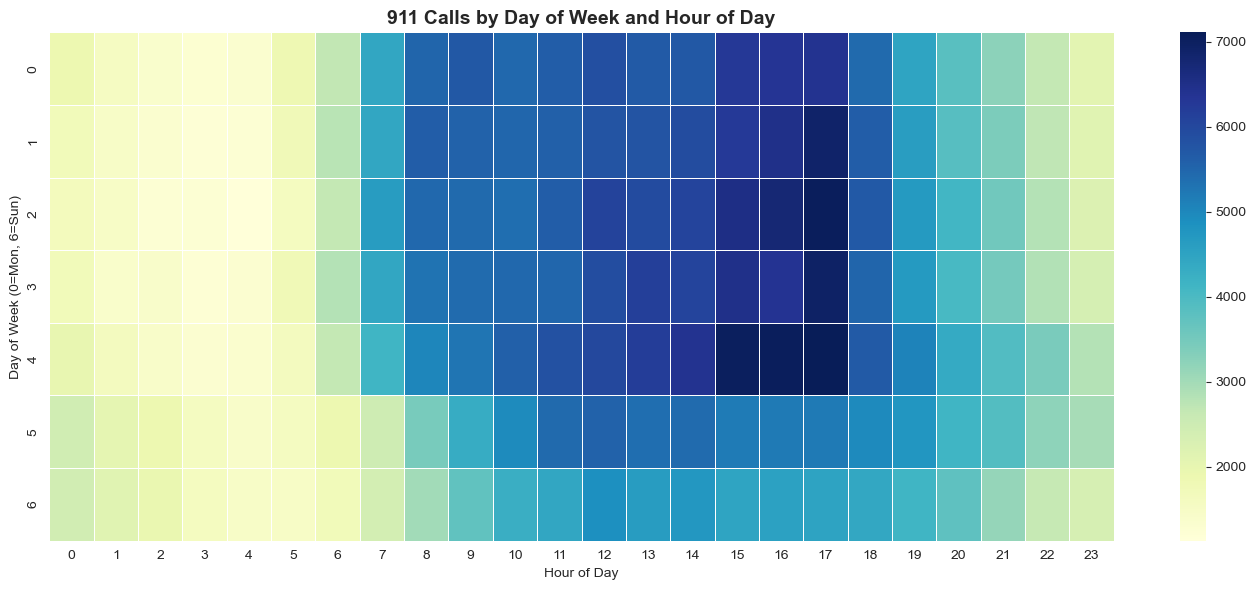

In [19]:
# Extract day of week and hour
df['DayOfWeek'] = df['timeStamp'].dt.dayofweek
df['Hour'] = df['timeStamp'].dt.hour

# Create pivot table
calls_pivot = df.pivot_table(
    index='DayOfWeek',
    columns='Hour',
    values='e',
    aggfunc='count'
)

# Create figure
plt.figure(figsize=(14,6))

# Create heatmap
sns.heatmap(
    calls_pivot,
    cmap='YlGnBu',
    linewidths=0.5
)

# Add title and labels
plt.title('911 Calls by Day of Week and Hour of Day',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')

# Show chart
plt.tight_layout()
plt.show()

The heatmap reveals clear patterns in emergency call activity across both days of the week and hours of the day. Higher call volumes are represented by darker shades, which are most noticeable during daytime and late afternoon hours, especially between 12 PM and 5 PM. Weekdays generally show higher emergency activity compared to weekends, likely due to increased work, commuting, and public movement during business days.

The darkest regions appear around the late afternoon hours on weekdays, indicating peak emergency demand during busy daytime periods. In contrast, early morning hours between midnight and 6 AM consistently show lighter shades across all days, suggesting lower emergency activity during overnight periods. Weekend patterns appear slightly more evenly distributed, with moderate activity extending later into the evening.

### Task 3    Create a boxplot comparing the latitude values across the three departments. What does the spread of latitude tell you about the geographic range of each department's calls?

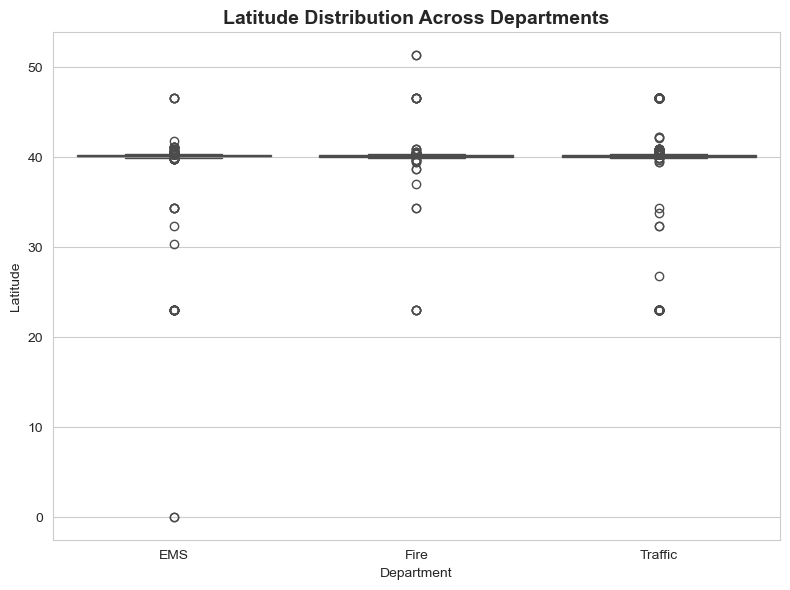

In [20]:
# Create figure
plt.figure(figsize=(8,6))

# Create boxplot
sns.boxplot(
    data=df,
    x='dept',
    y='lat',
    hue='dept',
    palette='deep',
    legend=False
)

# Add title and labels
plt.title('Latitude Distribution Across Departments',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Department')
plt.ylabel('Latitude')

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The boxplot shows that the latitude distributions for EMS, Fire, and Traffic departments are very similar, with most emergency calls concentrated around latitude 40. This suggests that all three departments primarily operate within the same geographic region. The relatively narrow boxes indicate that the majority of incidents occur within a concentrated area rather than being widely dispersed.

However, several outliers are visible across all departments, representing calls recorded at unusually high or low latitude values. Some extreme outliers, such as values near 0 or above 50, may indicate incorrect, missing, or anomalous geographic data. Overall, the spread of latitude values suggests that while most emergency calls occur within a consistent geographic range, a few unusual locations exist in the dataset.

### Task 4    Create a Seaborn countplot showing the top 5 reasons for EMS calls only. Filter the DataFrame first, then use value_counts() to identify the top 5 before plotting.

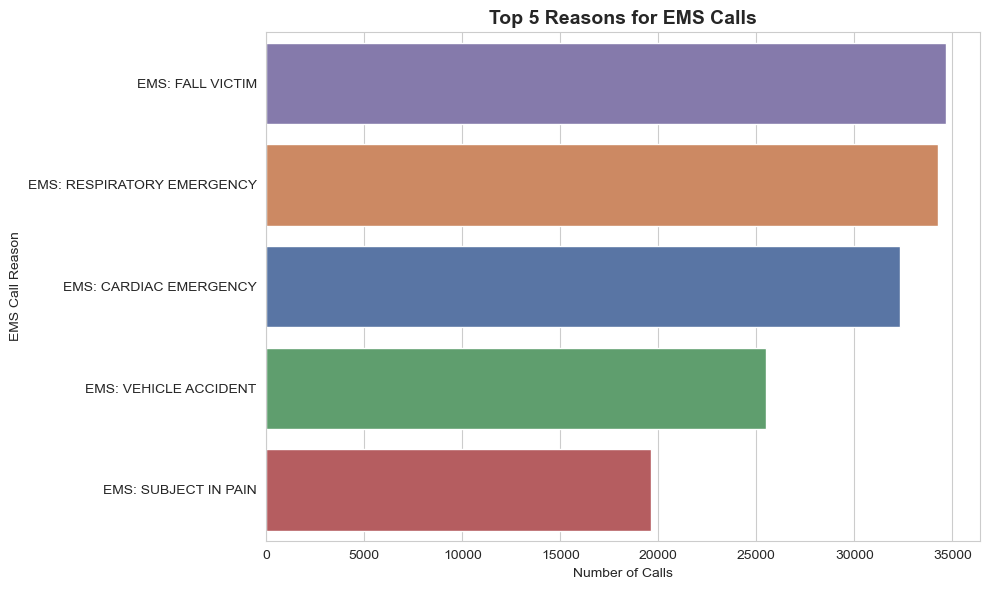

In [21]:
# Filter only EMS calls
ems_df = df[df['dept'] == 'EMS']

# Get top 5 EMS reasons
top_ems_reasons = ems_df['title'].value_counts().head(5)

# Create figure
plt.figure(figsize=(10,6))

# Create countplot
sns.countplot(
    data=ems_df[ems_df['title'].isin(top_ems_reasons.index)],
    y='title',
    hue='title',
    palette='deep',
    legend=False,
    order=top_ems_reasons.index
)

# Add title and labels
plt.title('Top 5 Reasons for EMS Calls',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Number of Calls')
plt.ylabel('EMS Call Reason')

# Improve layout
plt.tight_layout()

# Show chart
plt.show()

The day-hour heatmap reveals that emergency call activity is highest during weekday afternoons and early evenings, particularly around 4 PM to 5 PM. The darkest regions on the heatmap suggest that the combination of weekday rush hours, work-related movement, and increased daytime activity contributes to the highest emergency demand during these periods. In contrast, the fewest emergency calls occur during the overnight and early morning hours, especially between 2 AM and 5 AM across most days of the week. This overnight pattern is likely due to reduced public activity, lighter traffic, and fewer work or social events occurring during sleeping hours.